In [52]:
# 06_merge_and_clean_data.ipynb
# Merge college production with draft AV

import pandas as pd
import numpy as np
from pathlib import Path

# Directories
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [53]:
merged_df = pd.read_csv(RAW_DIR / "combine_vs_av_2000_2026.csv")

print(merged_df.shape)

(6644, 26)


In [54]:
merged_df.columns

Index(['season', 'round', 'pick', 'team', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'dr_av', 'player_name', 'pos', 'school', 'ht', 'wt', 'forty', 'bench',
       'vertical', 'broad_jump', 'cone', 'shuttle'],
      dtype='str')

In [55]:
merged_df = merged_df[merged_df["season"] <= 2020]

print("After removing recent years:", merged_df.shape)

After removing recent years: (5350, 26)


In [56]:
print("Missing dr_av:", merged_df["dr_av"].isna().sum())

Missing dr_av: 871


In [57]:
print("Before drop:", merged_df.shape)
merged_df = merged_df.dropna(subset=["dr_av"])
print("After drop:", merged_df.shape)

Before drop: (5350, 26)
After drop: (4479, 26)


In [58]:
merged_df["position"].value_counts()

position
DB     659
WR     570
LB     502
DE     396
RB     367
DT     358
T      337
TE     267
G      239
QB     182
CB     152
S      111
C      107
OLB     60
FB      38
P       37
K       36
ILB     29
NT      13
OL      12
LS       4
DL       3
Name: count, dtype: int64

In [59]:
pos_stats = (
    merged_df
    .groupby("position")["dr_av"]
    .agg(["count", "mean", "std"])
    .sort_values("count", ascending=False)
)

pos_stats

,count,mean,std
position,,,
DB,659,11.732929,14.454467
WR,570,13.173684,18.261131
LB,502,15.043825,19.274104
DE,396,16.133838,19.959700
RB,367,14.648501,18.051207
DT,358,14.865922,18.953841
T,337,20.507418,21.382307
TE,267,8.617978,13.231177
G,239,16.087866,18.088619


In [60]:
position_map = {

    # Offensive line
    "T": "OL",
    "G": "OL",
    "C": "OL",
    "OT": "OL",
    "OL": "OL",

    # Defensive line
    "DE": "DL",
    "DT": "DL",
    "NT": "DL",
    "DL": "DL",

    # Linebackers
    "LB": "LB",
    "OLB": "LB",
    "ILB": "LB",

    # Defensive backs
    "DB": "DB",
    "CB": "DB",
    "S": "DB",
    "SAF": "DB",
    "FS": "DB",

    # Skill
    "QB": "QB",
    "RB": "RB",
    "FB": "RB",
    "WR": "WR",
    "TE": "TE"
}

merged_df["pos_group"] = merged_df["position"].map(position_map)

In [61]:
merged_df["pos_group"].value_counts()

pos_group
DB    922
DL    770
OL    695
LB    591
WR    570
RB    405
TE    267
QB    182
Name: count, dtype: int64

In [62]:
# ---------------------------------
# Create Position Group Column
# ---------------------------------

def map_position(position):
    if position == "QB":
        return "QB"
    elif position in ["RB", "WR", "TE", "FB"]:
        return "Skill"
    elif position in ["OL", "T", "G", "C"]:
        return "OL"
    elif position in ["DL", "DE", "DT", "LB"]:
        return "Front7"
    elif position in ["DB", "CB", "S"]:
        return "DB"
    else:
        return "Other"

merged_df["PosGroup"] = merged_df["position"].apply(map_position)

print("Position group counts:")
print(merged_df["PosGroup"].value_counts())

Position group counts:
PosGroup
Front7    1259
Skill     1242
DB         922
OL         695
QB         182
Other      179
Name: count, dtype: int64


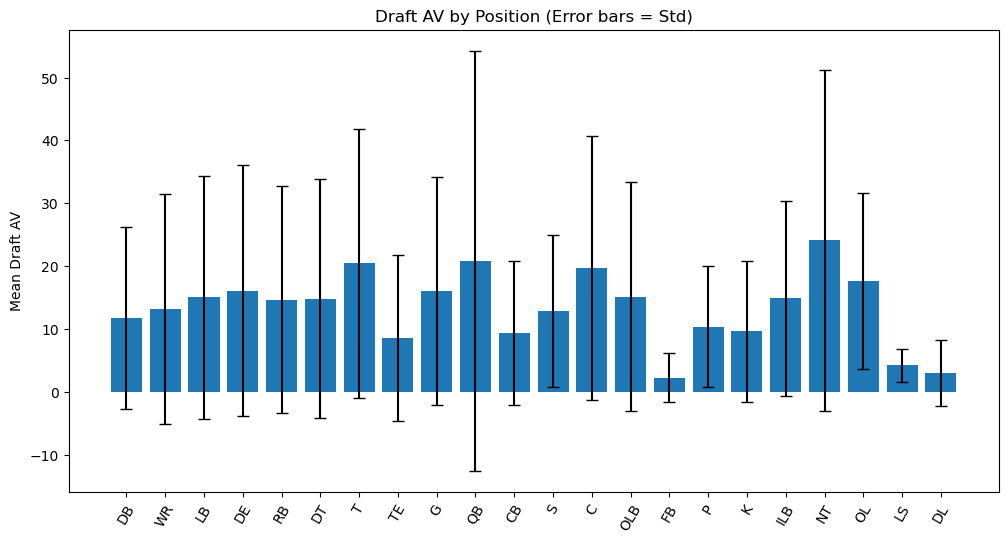

,count,mean,std
position,,,
DB,659,11.732929,14.454467
WR,570,13.173684,18.261131
LB,502,15.043825,19.274104
DE,396,16.133838,19.959700
RB,367,14.648501,18.051207
DT,358,14.865922,18.953841
T,337,20.507418,21.382307
TE,267,8.617978,13.231177
G,239,16.087866,18.088619


In [63]:
import matplotlib.pyplot as plt

pos_stats = (
    merged_df
    .groupby("position")["dr_av"]
    .agg(["count","mean","std"])
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    pos_stats.index,
    pos_stats["mean"],
    yerr=pos_stats["std"],
    capsize=4
)

plt.xticks(rotation=60)
plt.ylabel("Mean Draft AV")
plt.title("Draft AV by Position (Error bars = Std)")

plt.show()

pos_stats

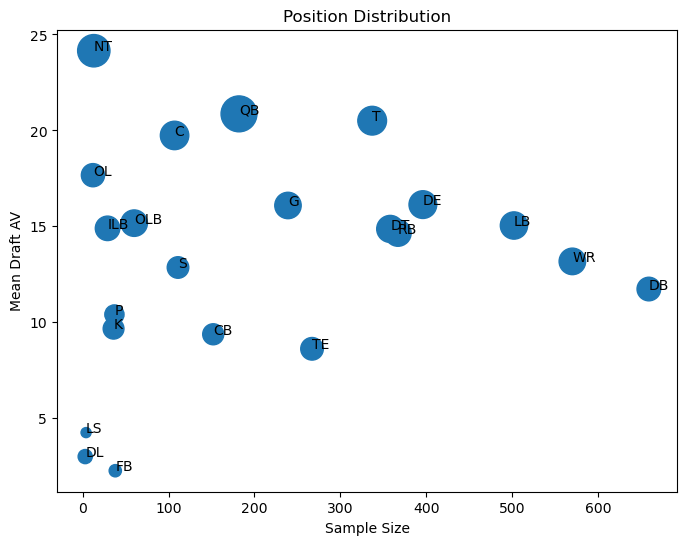

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(
    pos_stats["count"],
    pos_stats["mean"],
    s=pos_stats["std"]*20
)

for pos in pos_stats.index:
    plt.text(
        pos_stats.loc[pos,"count"],
        pos_stats.loc[pos,"mean"],
        pos
    )

plt.xlabel("Sample Size")
plt.ylabel("Mean Draft AV")
plt.title("Position Distribution")

plt.show()

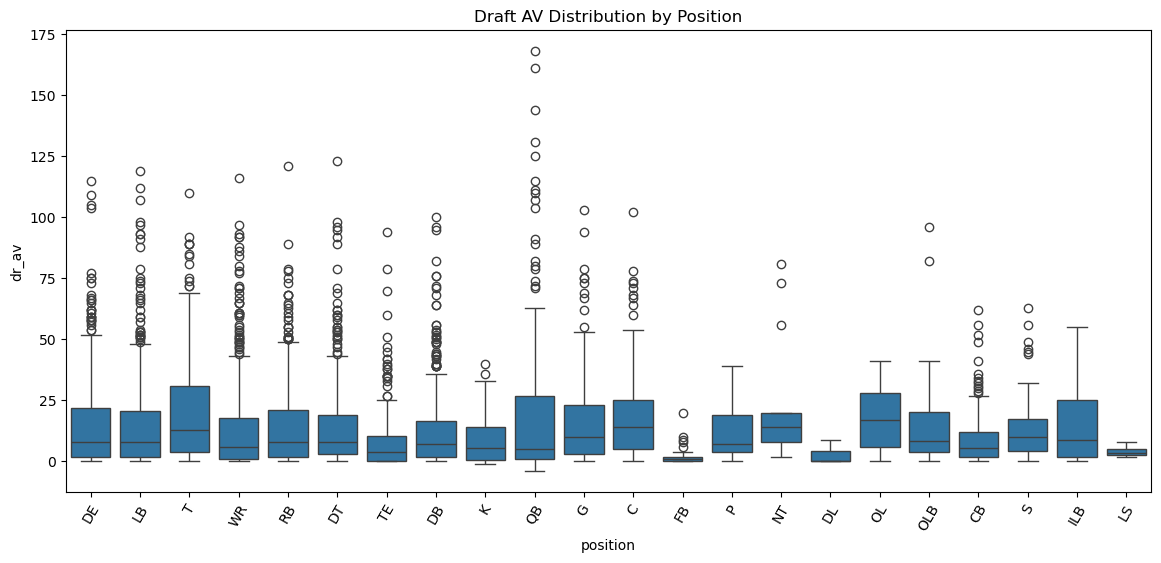

In [65]:
import seaborn as sns

plt.figure(figsize=(14,6))

sns.boxplot(
    x="position",
    y="dr_av",
    data=merged_df
)

plt.xticks(rotation=60)
plt.title("Draft AV Distribution by Position")

plt.show()

In [66]:
group_stats = (
    merged_df
    .groupby("pos_group")["dr_av"]
    .agg(["count","mean","std"])
    .sort_values("count", ascending=False)
)

group_stats

,count,mean,std
pos_group,,,
DB,922,11.479393,13.756535
DL,770,15.628571,19.626942
OL,695,18.820144,20.194391
LB,591,15.049069,18.969627
WR,570,13.173684,18.261131
RB,405,13.486420,17.597337
TE,267,8.617978,13.231177
QB,182,20.862637,33.390670


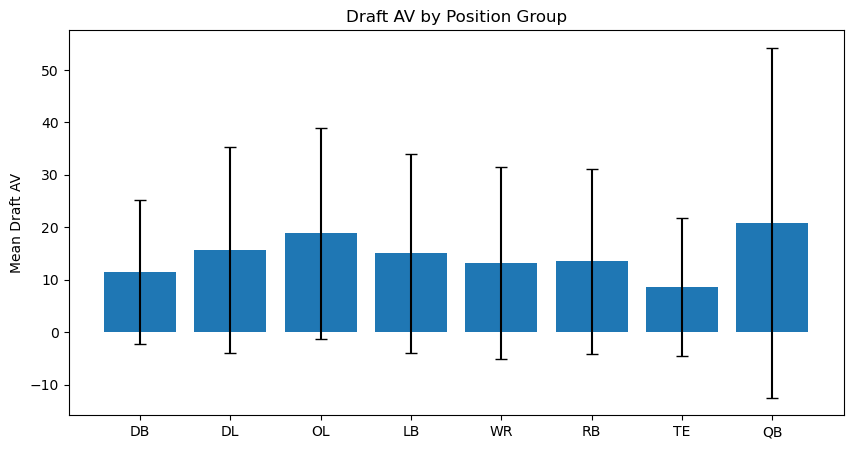

In [67]:
plt.figure(figsize=(10,5))

plt.bar(
    group_stats.index,
    group_stats["mean"],
    yerr=group_stats["std"],
    capsize=4
)

plt.ylabel("Mean Draft AV")
plt.title("Draft AV by Position Group")

plt.show()

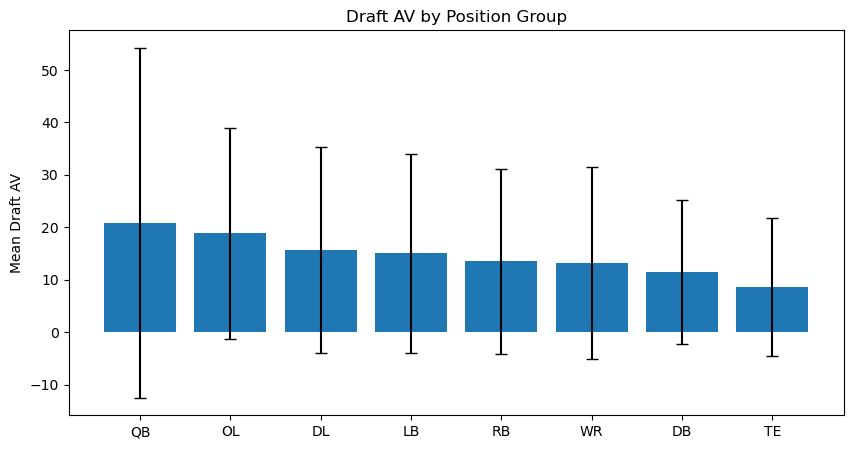

In [68]:
ordered = group_stats.sort_values("mean", ascending=False)

plt.figure(figsize=(10,5))

plt.bar(
    ordered.index,
    ordered["mean"],
    yerr=ordered["std"],
    capsize=4
)

plt.ylabel("Mean Draft AV")
plt.title("Draft AV by Position Group")

plt.show()

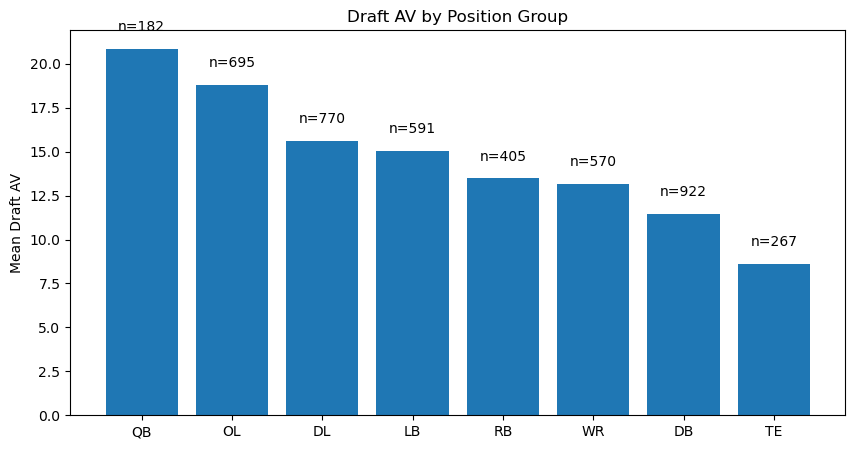

In [69]:
ordered = group_stats.sort_values("mean", ascending=False)

plt.figure(figsize=(10,5))

bars = plt.bar(
    ordered.index,
    ordered["mean"],
    capsize=4
)

for i, pos in enumerate(ordered.index):
    count = ordered.loc[pos,"count"]
    plt.text(i, ordered.loc[pos,"mean"] + 1, f"n={count}", ha="center")

plt.ylabel("Mean Draft AV")
plt.title("Draft AV by Position Group")

plt.show()

In [70]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

In [71]:
features = [
    "age",
    "ht",
    "wt",
    "forty",
    "bench",
    "vertical",
    "broad_jump",
    "cone",
    "shuttle",
    "pick"
]

target = "dr_av"

# To Aoi: the models are here, please fine tune the parameters (you can do in another notebook file), thank you

In [72]:
models = {

    "dummy": DummyRegressor(),

    "linear": LinearRegression(),

    "ridge": Ridge(alpha=1),

    "poly2": Pipeline([
        ("poly", PolynomialFeatures(2)),
        ("linear", LinearRegression())
    ]),

    "random_forest": RandomForestRegressor(
        n_estimators=200,
        random_state=0
    ),

    "adaboost": AdaBoostRegressor(
        n_estimators=200,
        random_state=0
    ),

    "gradboost": GradientBoostingRegressor(
        random_state=0
    ),

    "histboost": HistGradientBoostingRegressor(
        random_state=0
    ),

    "xgboost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=0
    ),

    "mlp": Pipeline([
        ("scale", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64,32),
            max_iter=500,
            random_state=0
        ))
    ])
}

In [73]:
results = []

groups = merged_df["pos_group"].dropna().unique()

for group in groups:

    df = merged_df[merged_df["pos_group"] == group]

    X = df[features]
    y = df[target]

    # drop missing rows
    mask = X.notna().all(axis=1)
    X = X[mask]
    y = y[mask]

    if len(X) < 50:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=0
    )

    for name, model in models.items():

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        results.append({
            "group": group,
            "model": name,
            "rmse": rmse,
            "mae": mae,
            "r2": r2
        })

c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  war

In [74]:
results_df = pd.DataFrame(results)

results_df

,group,model,rmse,mae,r2
0,DL,dummy,14.660787,12.238860,-0.095617
1,DL,linear,15.868521,12.864036,-0.283563
2,DL,ridge,15.831483,12.843677,-0.277578
3,DL,poly2,19.644881,15.814709,-0.967176
4,DL,random_forest,16.225554,12.734527,-0.341972
...,...,...,...,...,...
65,DB,adaboost,13.345765,11.767239,-0.501500
66,DB,gradboost,11.060138,8.817240,-0.031239
67,DB,histboost,11.597579,8.881614,-0.133895
68,DB,xgboost,11.736761,8.896311,-0.161275


In [75]:
best_models = results_df.loc[
    results_df.groupby("group")["r2"].idxmax()
]

best_models

,group,model,rmse,mae,r2
62,DB,ridge,10.629792,8.337003,0.047450
0,DL,dummy,14.660787,12.238860,-0.095617
14,LB,random_forest,17.502846,11.354057,0.340171
22,OL,ridge,20.164427,14.865411,0.131674
49,RB,mlp,20.908886,12.734318,0.253461
58,TE,xgboost,9.810419,7.522149,0.349493
37,WR,histboost,19.647318,12.570915,0.114863


In [76]:
best_models = results_df.loc[
    results_df.groupby("group")["r2"].idxmax()
]

best_models

,group,model,rmse,mae,r2
62,DB,ridge,10.629792,8.337003,0.047450
0,DL,dummy,14.660787,12.238860,-0.095617
14,LB,random_forest,17.502846,11.354057,0.340171
22,OL,ridge,20.164427,14.865411,0.131674
49,RB,mlp,20.908886,12.734318,0.253461
58,TE,xgboost,9.810419,7.522149,0.349493
37,WR,histboost,19.647318,12.570915,0.114863


In [77]:
for g in best_models["group"]:

    row = best_models[best_models["group"] == g].iloc[0]

    print(g)
    print("best model:", row["model"])
    print("R2:", round(row["r2"],3))
    print("RMSE:", round(row["rmse"],2))
    print()

DB
best model: ridge
R2: 0.047
RMSE: 10.63

DL
best model: dummy
R2: -0.096
RMSE: 14.66

LB
best model: random_forest
R2: 0.34
RMSE: 17.5

OL
best model: ridge
R2: 0.132
RMSE: 20.16

RB
best model: mlp
R2: 0.253
RMSE: 20.91

TE
best model: xgboost
R2: 0.349
RMSE: 9.81

WR
best model: histboost
R2: 0.115
RMSE: 19.65



In [78]:
for g in best_models["group"]:

    row = best_models[best_models["group"] == g].iloc[0]

    print(g)
    print("best model:", row["model"])
    print("R2:", round(row["r2"],3))
    print("RMSE:", round(row["rmse"],2))
    print()

DB
best model: ridge
R2: 0.047
RMSE: 10.63

DL
best model: dummy
R2: -0.096
RMSE: 14.66

LB
best model: random_forest
R2: 0.34
RMSE: 17.5

OL
best model: ridge
R2: 0.132
RMSE: 20.16

RB
best model: mlp
R2: 0.253
RMSE: 20.91

TE
best model: xgboost
R2: 0.349
RMSE: 9.81

WR
best model: histboost
R2: 0.115
RMSE: 19.65



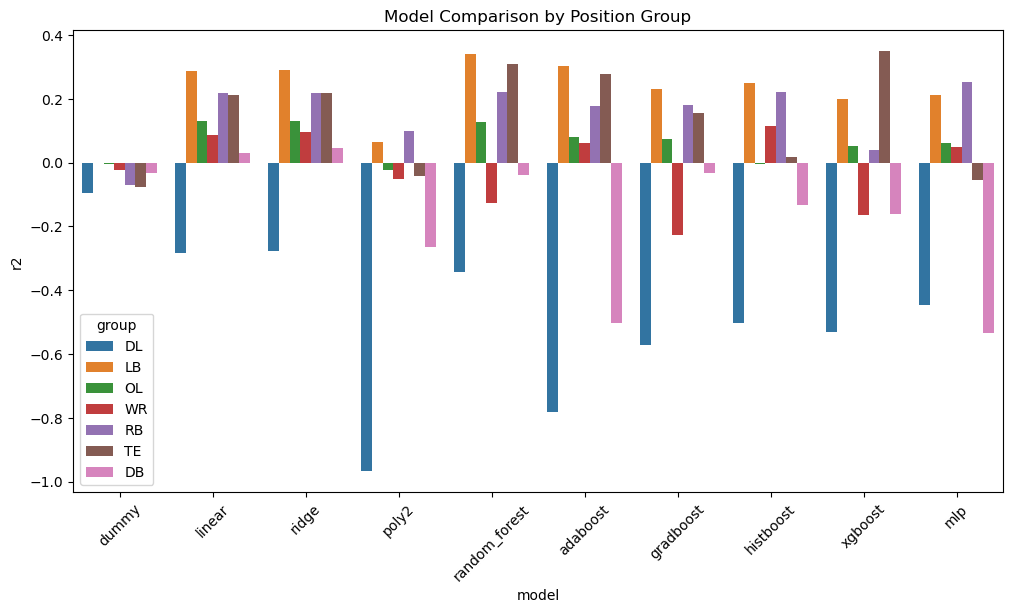

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="model",
    y="r2",
    hue="group"
)

plt.xticks(rotation=45)
plt.title("Model Comparison by Position Group")

plt.show()

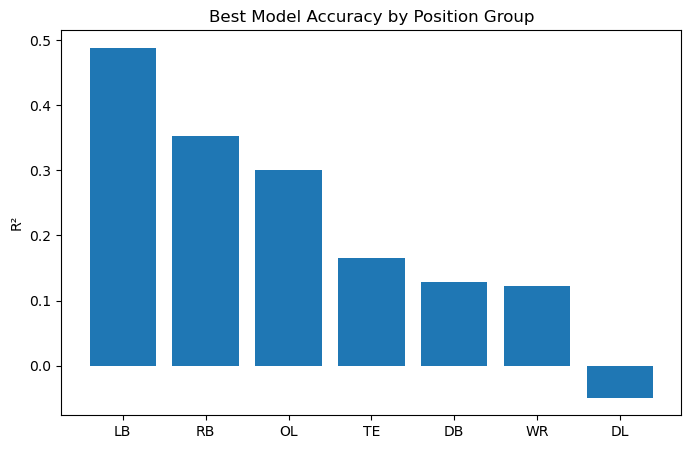

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "group": ["DB","DL","LB","OL","RB","TE","WR"],
    "r2": [0.128,-0.049,0.488,0.301,0.353,0.166,0.122]
}

df = pd.DataFrame(data)

df = df.sort_values("r2", ascending=False)

plt.figure(figsize=(8,5))

plt.bar(df["group"], df["r2"])

plt.ylabel("R²")
plt.title("Best Model Accuracy by Position Group")

plt.show()

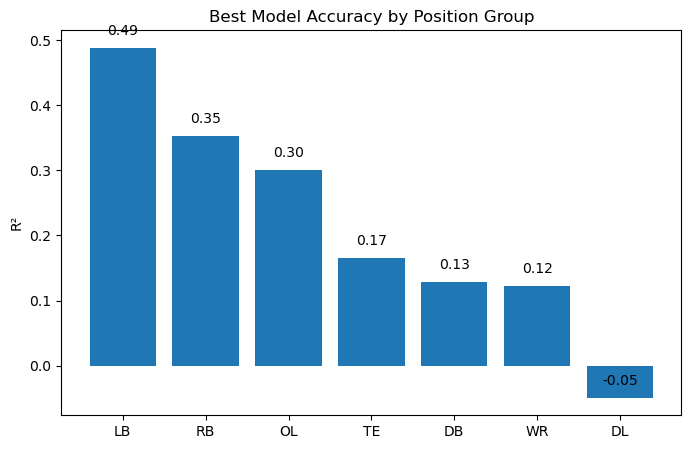

In [81]:
plt.figure(figsize=(8,5))

bars = plt.bar(df["group"], df["r2"])

for i, v in enumerate(df["r2"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.ylabel("R²")
plt.title("Best Model Accuracy by Position Group")

plt.show()

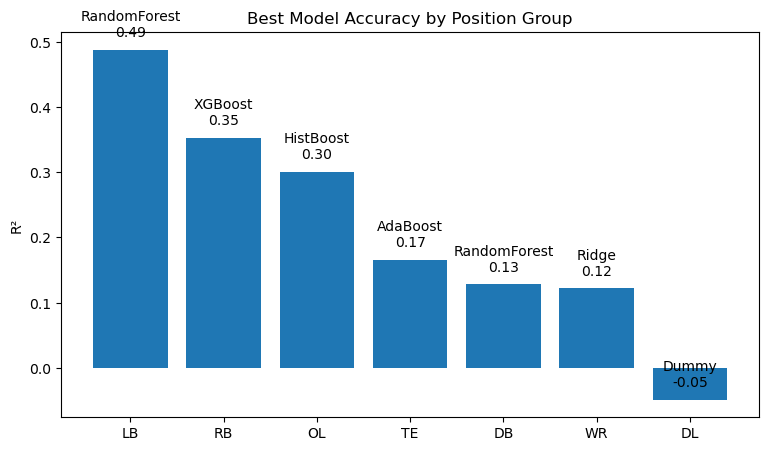

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "group": ["DB","DL","LB","OL","RB","TE","WR"],
    "model": [
        "RandomForest",
        "Dummy",
        "RandomForest",
        "HistBoost",
        "XGBoost",
        "AdaBoost",
        "Ridge"
    ],
    "r2": [0.128, -0.049, 0.488, 0.301, 0.353, 0.166, 0.122]
}

df = pd.DataFrame(data)

df = df.sort_values("r2", ascending=False)

plt.figure(figsize=(9,5))

bars = plt.bar(df["group"], df["r2"])

for i, row in df.iterrows():
    plt.text(
        df.index.get_loc(i),
        row["r2"] + 0.02,
        f"{row['model']}\n{row['r2']:.2f}",
        ha="center"
    )

plt.ylabel("R²")
plt.title("Best Model Accuracy by Position Group")

plt.show()

In [83]:
predictions = []

for group in merged_df["pos_group"].unique():

    df = merged_df[merged_df["pos_group"] == group]

    X = df[features]
    y = df["dr_av"]

    mask = X.notna().all(axis=1)
    X = X[mask]
    y = y[mask]

    if len(X) < 50:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0
    )

    # choose best model for this group
    if group == "LB":
        model = RandomForestRegressor(n_estimators=200)
    elif group == "RB":
        model = XGBRegressor(n_estimators=200)
    elif group == "OL":
        model = HistGradientBoostingRegressor()
    elif group == "TE":
        model = AdaBoostRegressor(n_estimators=200)
    elif group == "WR":
        model = Ridge()
    elif group == "DB":
        model = RandomForestRegressor(n_estimators=200)
    else:
        model = DummyRegressor()

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    temp = pd.DataFrame({
        "group": group,
        "actual": y_test,
        "pred": preds
    })

    predictions.append(temp)

pred_df = pd.concat(predictions)


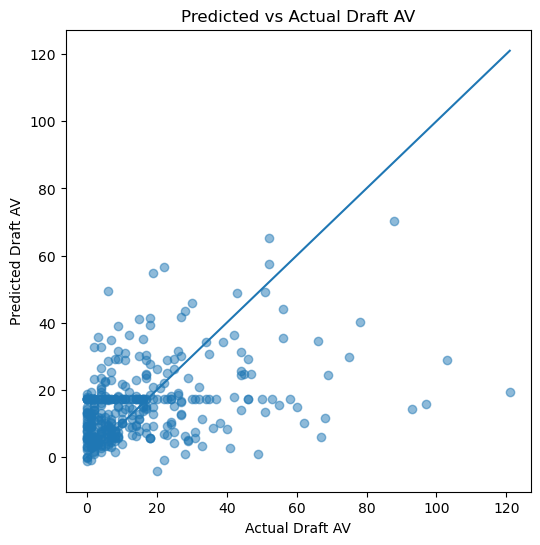

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(pred_df["actual"], pred_df["pred"], alpha=0.5)

plt.xlabel("Actual Draft AV")
plt.ylabel("Predicted Draft AV")

plt.title("Predicted vs Actual Draft AV")

# diagonal reference line
max_val = max(pred_df["actual"].max(), pred_df["pred"].max())

plt.plot([0, max_val], [0, max_val])

plt.show()

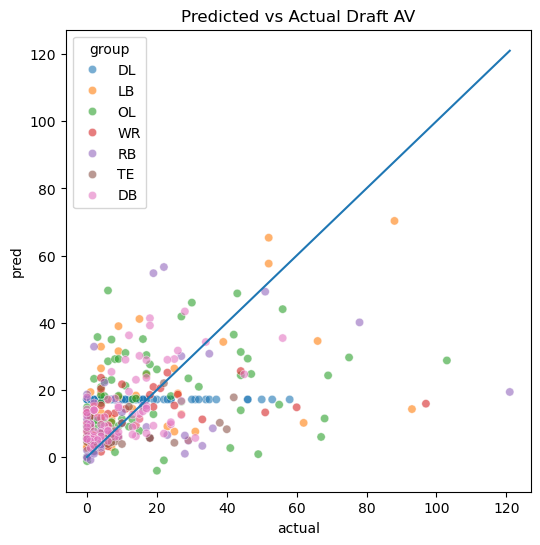

In [85]:
import seaborn as sns

plt.figure(figsize=(6,6))

sns.scatterplot(
    data=pred_df,
    x="actual",
    y="pred",
    hue="group",
    alpha=0.6
)

max_val = max(pred_df["actual"].max(), pred_df["pred"].max())

plt.plot([0,max_val],[0,max_val])

plt.title("Predicted vs Actual Draft AV")

plt.show()

In [86]:
model = HistGradientBoostingRegressor()

X = merged_df[features]
y = merged_df["dr_av"]

mask = X.notna().all(axis=1)

X = X[mask]
y = y[mask]

model.fit(X, y)

,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [87]:
from sklearn.metrics import r2_score

r2_by_year = {}

years = merged_df["season"].unique()

for year in sorted(years):

    df = merged_df[merged_df["season"] == year]

    X_year = df[features]
    y_year = df["dr_av"]

    mask = X_year.notna().all(axis=1)

    X_year = X_year[mask]
    y_year = y_year[mask]

    if len(X_year) < 10:
        continue

    preds = model.predict(X_year)

    r2_by_year[year] = r2_score(y_year, preds)

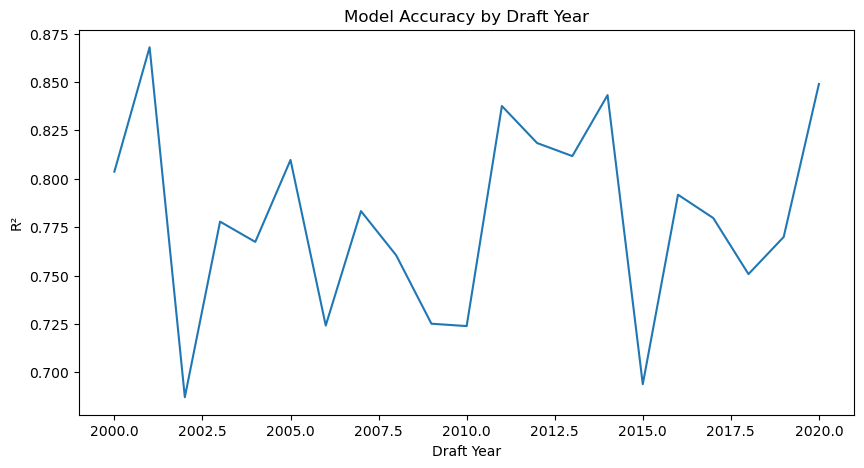

In [88]:
years = list(r2_by_year.keys())
scores = list(r2_by_year.values())

plt.figure(figsize=(10,5))

plt.plot(years, scores)

plt.xlabel("Draft Year")
plt.ylabel("R²")

plt.title("Model Accuracy by Draft Year")

plt.show()

In [89]:
baseline = LinearRegression()

X_pick = merged_df[["pick"]]
y = merged_df["dr_av"]

baseline.fit(X_pick, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [90]:
pick_r2 = {}

for year in sorted(years):

    df = merged_df[merged_df["season"] == year]

    X_year = df[["pick"]]
    y_year = df["dr_av"]

    preds = baseline.predict(X_year)

    pick_r2[year] = r2_score(y_year, preds)

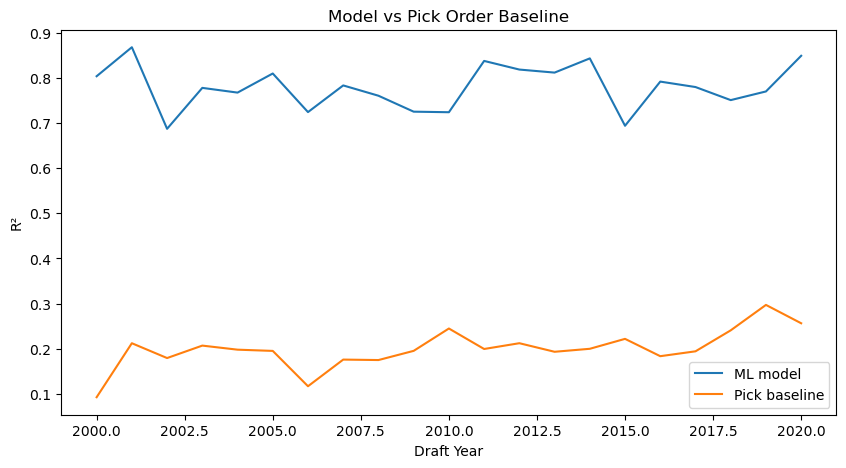

In [91]:
plt.figure(figsize=(10,5))

plt.plot(years, scores, label="ML model")

plt.plot(years, list(pick_r2.values()), label="Pick baseline")

plt.xlabel("Draft Year")
plt.ylabel("R²")

plt.title("Model vs Pick Order Baseline")

plt.legend()

plt.show()

In [92]:
best_models = {
    "DB": RandomForestRegressor(n_estimators=200, random_state=0),
    "DL": DummyRegressor(),
    "LB": RandomForestRegressor(n_estimators=200, random_state=0),
    "OL": HistGradientBoostingRegressor(random_state=0),
    "RB": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=0),
    "TE": AdaBoostRegressor(n_estimators=200, random_state=0),
    "WR": Ridge()
}

In [93]:
trained_models = {}

for group, model in best_models.items():

    df = merged_df[merged_df["pos_group"] == group]

    X = df[features]
    y = df["dr_av"]

    mask = X.notna().all(axis=1)

    X = X[mask]
    y = y[mask]

    if len(X) < 30:
        continue

    model.fit(X, y)

    trained_models[group] = model

In [94]:
pred_list = []

for group, model in trained_models.items():

    df = merged_df[merged_df["pos_group"] == group]

    X = df[features]
    y = df["dr_av"]

    mask = X.notna().all(axis=1)

    X = X[mask]
    y = y[mask]

    preds = model.predict(X)

    temp = df.loc[X.index].copy()

    temp["pred_av"] = preds

    pred_list.append(temp)

pred_df = pd.concat(pred_list)

In [95]:
from sklearn.metrics import r2_score

year_r2 = {}

for year in sorted(pred_df["season"].unique()):

    df = pred_df[pred_df["season"] == year]

    if len(df) < 10:
        continue

    r2 = r2_score(df["dr_av"], df["pred_av"])

    year_r2[year] = r2

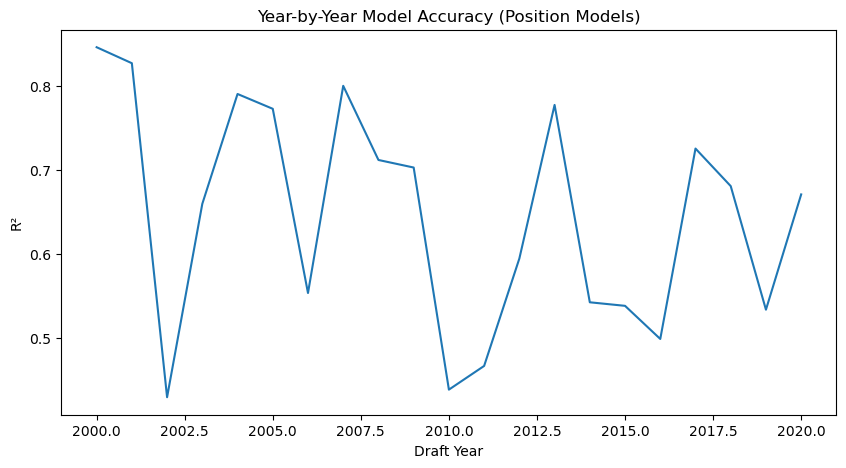

In [96]:
import matplotlib.pyplot as plt

years = list(year_r2.keys())
scores = list(year_r2.values())

plt.figure(figsize=(10,5))

plt.plot(years, scores)

plt.xlabel("Draft Year")
plt.ylabel("R²")

plt.title("Year-by-Year Model Accuracy (Position Models)")

plt.show()

In [97]:
pick_r2 = {}

for year in sorted(pred_df["season"].unique()):

    df = merged_df[merged_df["season"] == year]

    preds = baseline.predict(df[["pick"]])

    r2 = r2_score(df["dr_av"], preds)

    pick_r2[year] = r2

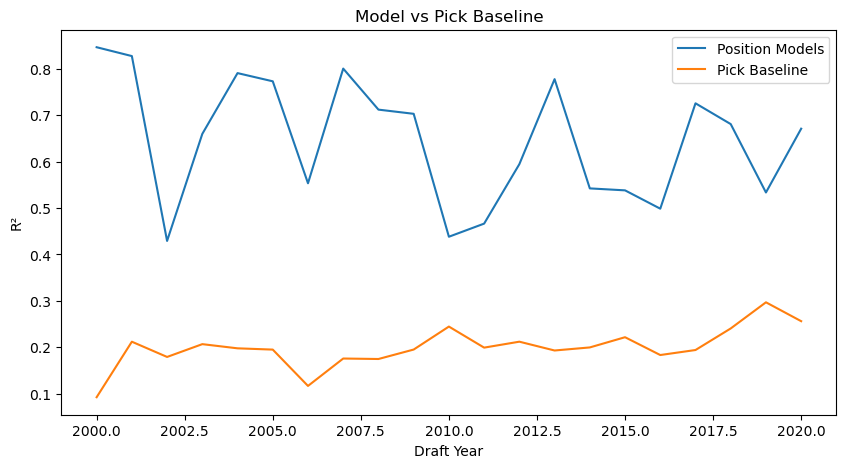

In [98]:
plt.figure(figsize=(10,5))

plt.plot(years, scores, label="Position Models")

plt.plot(years, list(pick_r2.values()), label="Pick Baseline")

plt.xlabel("Draft Year")
plt.ylabel("R²")

plt.title("Model vs Pick Baseline")

plt.legend()

plt.show()

In [100]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# models to test
model_dict = {
    "dummy": DummyRegressor(),
    "linear": LinearRegression(),
    "ridge": Ridge(alpha=1),
    "random_forest": RandomForestRegressor(n_estimators=200, random_state=0),
    "adaboost": AdaBoostRegressor(n_estimators=200, random_state=0),
    "gradboost": GradientBoostingRegressor(random_state=0),
    "histboost": HistGradientBoostingRegressor(random_state=0),
    "xgboost": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=0),
    "mlp": Pipeline([
        ("scale", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=0))
    ])
}

features = [
    "age","ht","wt","forty","bench","vertical",
    "broad_jump","cone","shuttle","pick"
]

target = "dr_av"

years = sorted(merged_df["season"].unique())
groups = merged_df["pos_group"].dropna().unique()

results = []

for year in years:

    train_df = merged_df[merged_df["season"] < year]
    test_df  = merged_df[merged_df["season"] == year]

    if len(test_df) < 10:
        continue

    year_preds = []
    year_actual = []

    for group in groups:

        train_g = train_df[train_df["pos_group"] == group]
        test_g  = test_df[test_df["pos_group"] == group]

        if len(train_g) < 50 or len(test_g) < 5:
            continue

        X_train = train_g[features]
        y_train = train_g[target]



        mask = X_train.notna().all(axis=1)
        X_train = X_train[mask]
        y_train = y_train[mask]

        # skip if no data
        if len(X_train) < 10:
            continue

        X_test = test_g[features]
        y_test = test_g[target]

        mask = X_test.notna().all(axis=1)
        X_test = X_test[mask]
        y_test = y_test[mask]

        best_model = None
        best_name = None
        best_train_r2 = -np.inf

        # choose best model using training performance
        for name, model in model_dict.items():

            m = model
            m.fit(X_train, y_train)

            preds_train = m.predict(X_train)
            train_r2 = r2_score(y_train, preds_train)

            if train_r2 > best_train_r2:
                best_train_r2 = train_r2
                best_model = m
                best_name = name

        preds = best_model.predict(X_test)

        year_preds.extend(preds)
        year_actual.extend(y_test)

        results.append({
            "year": year,
            "group": group,
            "model": best_name,
            "train_r2": best_train_r2
        })

    if len(year_actual) > 0:

        test_r2 = r2_score(year_actual, year_preds)

        results.append({
            "year": year,
            "group": "ALL",
            "model": "combined",
            "train_r2": None,
            "test_r2": test_r2
        })

results_df = pd.DataFrame(results)

print(results_df.head())

c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  war

   year group      model  train_r2   test_r2
0  2002    DL  gradboost  0.999994       NaN
1  2002    LB  gradboost  0.999998       NaN
2  2002    OL    xgboost  0.999923       NaN
3  2002    DB    xgboost  0.999841       NaN
4  2002   ALL   combined       NaN -0.371891


c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [101]:
model_year = results_df[results_df["group"] == "ALL"][["year","test_r2"]].dropna()

model_year = model_year.sort_values("year")

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

pick_r2 = []

years = sorted(merged_df["season"].unique())

for year in years:

    train_df = merged_df[merged_df["season"] < year]
    test_df  = merged_df[merged_df["season"] == year]

    if len(train_df) < 50 or len(test_df) < 10:
        continue

    model = LinearRegression()

    model.fit(train_df[["pick"]], train_df["dr_av"])

    preds = model.predict(test_df[["pick"]])

    r2 = r2_score(test_df["dr_av"], preds)

    pick_r2.append({
        "year": year,
        "baseline_r2": r2
    })

pick_df = pd.DataFrame(pick_r2)

In [103]:
plot_df = pd.merge(model_year, pick_df, on="year")

plot_df = plot_df.sort_values("year")

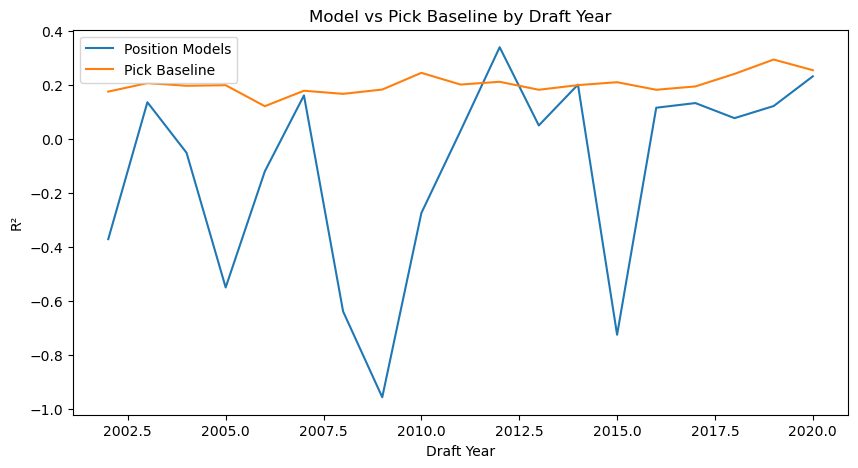

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(plot_df["year"], plot_df["test_r2"], label="Position Models")
plt.plot(plot_df["year"], plot_df["baseline_r2"], label="Pick Baseline")

plt.xlabel("Draft Year")
plt.ylabel("R²")
plt.title("Model vs Pick Baseline by Draft Year")

plt.legend()

plt.show()

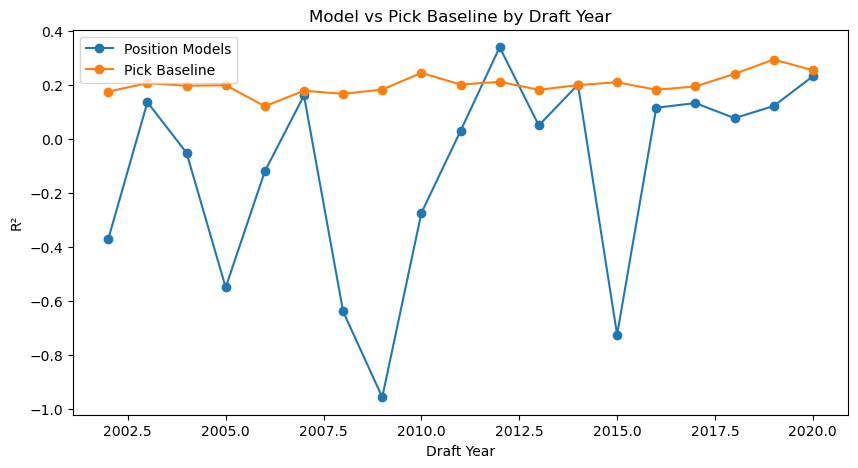

In [105]:
plt.figure(figsize=(10,5))

plt.plot(plot_df["year"], plot_df["test_r2"], marker="o", label="Position Models")
plt.plot(plot_df["year"], plot_df["baseline_r2"], marker="o", label="Pick Baseline")

plt.xlabel("Draft Year")
plt.ylabel("R²")
plt.title("Model vs Pick Baseline by Draft Year")

plt.legend()

plt.show()